# 2.8 Gaussian city with relocations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Integration test (no figures saved)

2025-09-26 09:07:04,061 - INFO - Initializing city
2025-09-26 09:07:04,065 - INFO - Calculating density profile for 1 core(s)
2025-09-26 09:07:04,070 - INFO - Running simulation for 5000 steps
2025-09-26 09:07:05,406 - INFO - Simulation completed in 1.34 seconds
2025-09-26 09:07:05,409 - INFO - In-simulation time passed: 7 days
2025-09-26 09:07:05,410 - INFO - Overall, statistics gathered over: 3 days
2025-09-26 09:07:05,412 - INFO - Cumulative rentals happened: 6097
2025-09-26 09:07:05,412 - INFO - Average rentals per car per day: 4.56
2025-09-26 09:07:05,413 - INFO - Average rental time per trip, min: 14.88
2025-09-26 09:07:05,414 - INFO - Average CM1 gain per trip, Eur: 3.72
2025-09-26 09:07:05,415 - INFO - Overall CM2 profit per day, Eur: -1517.51


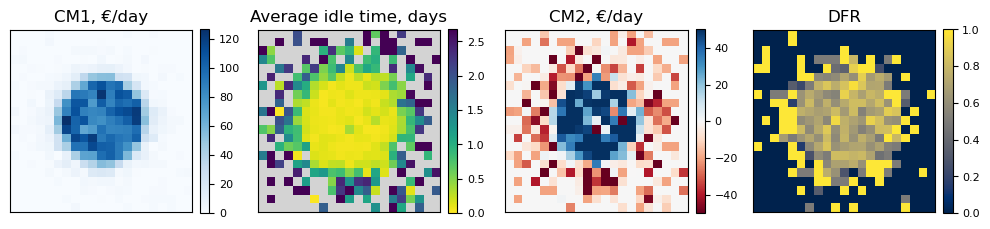

In [2]:
# Testing grounds, not a real figure
config = {
    "seed": 1,  # Random seed
    "city_width": 21, # km
    "initial_r": 5, # km
    "grid_step": 1, # km. Use 1 for ~intermediate resolution
    "density_sigma": 5, # Gaussian sigma. A bit smaller than default, to have close-to-zero demands
    "n_cars": 500,
    "settle_down_steps": 3000, # Number of steps without stats collection, for the system to settle down
    "p_factor": 0.06,  # The simplest way to regulate trips/car/day and city profitability
    "tick_in_minutes": 2,
}

import matplotlib.pyplot as plt
from city_simulator import City

city = City(config)
city.init_cars()
city.simulate(5000)
plt.figure(figsize=(10, 5))
city.visualize(plots=["cm1", "idle_times", "cm2", "dfr"])

In [3]:
stop_here()  # Intentional crash

NameError: name 'stop_here' is not defined

# Typical stats - base state (no relocations, no price shenanigans, one core)

2025-07-01 10:30:52,606 - INFO - Initializing city
2025-07-01 10:30:52,609 - INFO - Calculating density profile for 1 core(s)
2025-07-01 10:30:52,628 - INFO - Running simulation for 30000 steps
2025-07-01 10:30:56,436 - INFO - ..Simulating step 5000 of 30000
2025-07-01 10:31:01,533 - INFO - ..Simulating step 10000 of 30000
2025-07-01 10:31:06,460 - INFO - ..Simulating step 15000 of 30000
2025-07-01 10:31:11,092 - INFO - ..Simulating step 20000 of 30000
2025-07-01 10:31:16,050 - INFO - ..Simulating step 25000 of 30000
2025-07-01 10:31:20,827 - INFO - Simulation completed in 28.20 seconds
2025-07-01 10:31:20,829 - INFO - In-simulation time passed: 42 days
2025-07-01 10:31:20,831 - INFO - Overall, statistics gathered over: 37 days
2025-07-01 10:31:20,832 - INFO - Cumulative rentals happened: 76780
2025-07-01 10:31:20,833 - INFO - Average rentals per car per day: 4.12
2025-07-01 10:31:20,834 - INFO - Average rental time per trip, min: 17.70
2025-07-01 10:31:20,835 - INFO - Average CM1 gain

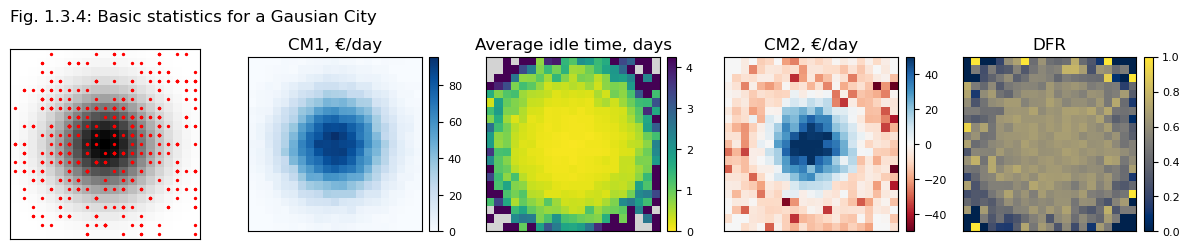

In [ ]:
# Nice Gaussian city
config = {
    "seed": 1,  # Random seed
    "city_width": 21, # km
    "initial_r": 5, # km
    "grid_step": 1, # km. Use 1 for ~intermediate resolution
    "density_sigma": 5, # Gaussian sigma. A bit smaller than default, to have close-to-zero demands
    "n_cars": 500,
    "settle_down_steps": 3000, # Number of steps without stats collection, for the system to settle down
    "p_factor": 0.06,  # The simplest way to regulate trips/car/day and city profitability
    "tick_in_minutes": 2,
}

import numpy as np
import matplotlib.pyplot as plt
from city_simulator import City

city = City(config)
city.init_cars()
city.simulate(30000)
plt.figure(figsize=(12, 3))
city.visualize()
f = plt.gcf()
ax = f.axes[0]
ax.set_title("")  # Clear the title
for text in ax.texts:
    text.remove()
ax.set_title("", pad=0)  # Clear the title
ax.set_title("Fig. 1.3.4: Basic statistics for a Gausian City", loc='left', pad=20)
plt.tight_layout();
plt.savefig("../figures/01simple_03city_04stats_maps.svg", dpi=300)

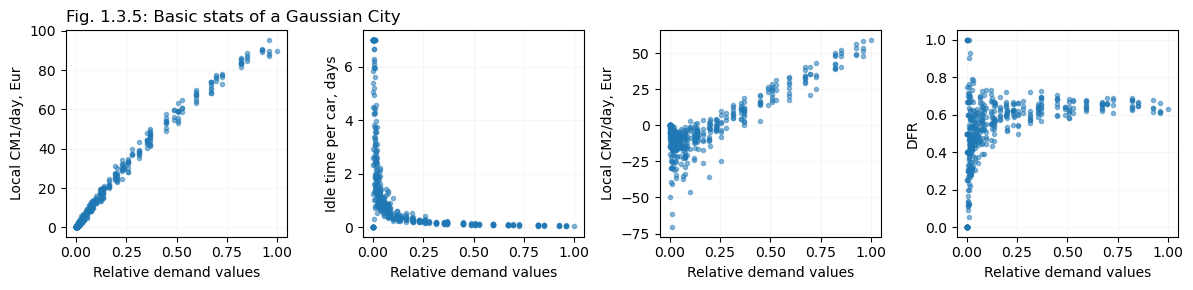

In [ ]:
# Stats, use data from the previous run 👆

demand = city.demand.flatten()
cm1 = city.map_cm1.flatten() / city.n_days
cm2 = city.map_cm2.flatten() / city.n_days
idle_times = city.map_idle_time.flatten() * city.tick_in_minutes / 60 / 24 / np.maximum(1, city.map_n_rentals.flatten())
dfr = city.map_n_rentals.flatten() / np.maximum(1, city.map_n_appops.flatten())

plt.figure(figsize=(12, 3))
plt.subplot(141)
plt.title("Fig. 1.3.5: Basic stats of a Gaussian City", loc='left');
plt.plot(demand, cm1, '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.xlabel("Relative demand values")
plt.ylabel("Local CM1/day, Eur")

plt.subplot(142)
plt.plot(demand, np.minimum(7, idle_times), '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.xlabel("Relative demand values")
plt.ylabel("Idle time per car, days")

plt.subplot(143)
plt.plot(demand, cm2, '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.xlabel("Relative demand values")
plt.ylabel("Local CM2/day, Eur")

plt.subplot(144)
plt.plot(demand, dfr, '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.xlabel("Relative demand values")
plt.ylabel("DFR")

plt.tight_layout();
plt.savefig("../figures/01simple_03city_05stats_plots.svg", dpi=300)

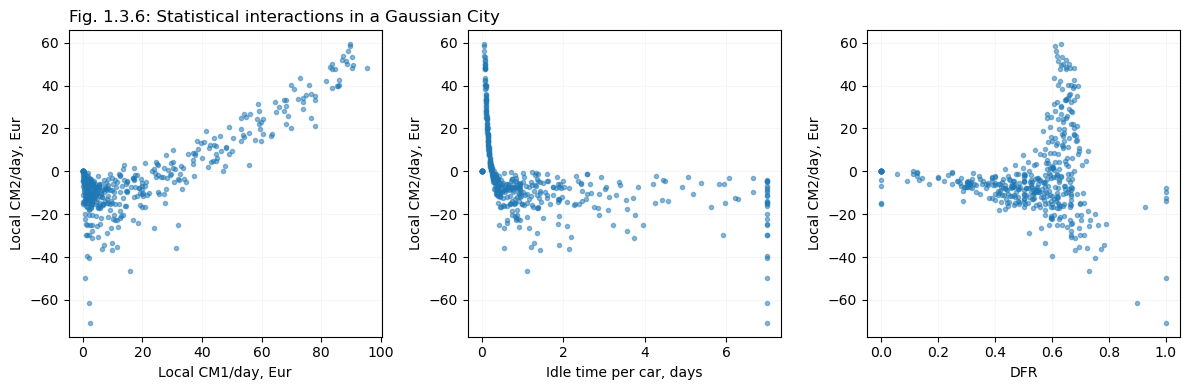

In [ ]:
# Fancier stats (from the same run)

plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.title("Fig. 1.3.6: Statistical interactions in a Gaussian City", loc='left');
plt.plot(cm1, cm2, '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.ylabel("Local CM2/day, Eur")
plt.xlabel("Local CM1/day, Eur")

plt.subplot(132)
plt.plot(np.minimum(idle_times, 7), cm2, '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.xlabel("Idle time per car, days")
plt.ylabel("Local CM2/day, Eur")

plt.subplot(133)
plt.plot(dfr, cm2, '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.xlabel("DFR")
plt.ylabel("Local CM2/day, Eur")

plt.tight_layout();
plt.savefig("../figures/01simple_03city_06stats2_plots.svg", dpi=300)